# <h1 style="text-align: center; font-weight: bolder;">LAB 8</h1>
# <h1 style="text-align: center; font-weight: bold;">TRANSFORMERS</h1>

This notebook trains a transformer encoder model on MagnaTagATune (MTAT) for multi-label music tagging.
It is self-contained: installs dependencies, loads MTAT (local if available), trains, evaluates with ROC-AUC and PR-AUC,
and reports compute/resource + emissions metrics.

URL for Google Colab: 

URL for GitHub repo: 

URL for MTAT dataset in GoogleDrive: https://drive.google.com/drive/folders/1urEa6g919ewcRfHIU_RDX4B5yIeuG67C?usp=sharing

# <h2 style="text-align: center; font-weight: bold;">SETUP</h2>


# <h3 style="text-align: left; font-weight: bold;">DEPENDENCIES</h3>


In [40]:
import sys, platform, os, time, math, random, shutil, subprocess

def in_colab():
    return "google.colab" in sys.modules

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# Install only on Colab (local -> usa tu venv)
if in_colab():
    pip_install([
        "torch", "torchaudio",
        "tqdm", "scikit-learn", "matplotlib",
        "psutil", "codecarbon",
        "pandas", "numpy",
        "soundfile"
    ])
    # ffmpeg for mp3
    if shutil.which("ffmpeg") is None:
        subprocess.check_call(["apt-get", "update", "-y"])
        subprocess.check_call(["apt-get", "install", "-y", "ffmpeg"])
else:
    print("Local env -> skipping pip installs (use your venv).")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import pandas as pd

from torch.utils.data import Dataset, DataLoader
from torchaudio.transforms import MelSpectrogram
from tqdm.auto import tqdm

from sklearn.metrics import roc_auc_score, average_precision_score
import psutil
from codecarbon import OfflineEmissionsTracker

class color:
   PURPLE = '\033[95m'
   CYAN = '\033[96m'
   DARKCYAN = '\033[36m'
   BLUE = '\033[94m'
   GREEN = '\033[92m'
   YELLOW = '\033[93m'
   RED = '\033[91m'
   BOLD = '\033[1m'
   UNDERLINE = '\033[4m'
   END = '\033[0m'

print("python:", sys.version)
print("platform:", platform.platform())
print("colab:", in_colab())
print("ffmpeg:", shutil.which("ffmpeg"))
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)

Local env -> skipping pip installs (use your venv).
python: 3.11.14 (main, Oct  9 2025, 16:16:55) [Clang 17.0.0 (clang-1700.4.4.1)]
platform: macOS-26.1-arm64-arm-64bit
colab: False
ffmpeg: /opt/homebrew/bin/ffmpeg
torch: 2.9.1
torchaudio: 2.9.1


# <h3 style="text-align: left; font-weight: bold;">DEVICES (M1, CUDA OR CPU) & SCALABILITY</h3>


In [41]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    # Mac M1
    device = "mps"   
else:
    device = "cpu"
device

'mps'

# <h3 style="text-align: left; font-weight: bold;">CONFIG</h3>


In [42]:

CFG = {
    "mode": "tl",

    # audio
    "sample_rate": 16000,
    "clip_seconds": 2.0,
    "n_fft": 1024,
    "n_mels": 64,

    # training
    "batch_size": 32,
    "epochs": 10,
    "lr": 1e-3,

    # defaults (se sobreescriben abajo)
    "num_workers": 0,
    "pin_memory": False,

    # dataset
    "max_train_items": 8000,
    "max_val_items": 2000,
    "max_test_items": 2000,

    # baseline transformer
    "n_blocks": 2,
    "emb_dim": 64,
    "n_heads": 4,
    "stride": (4,4),
    "pos_enc_gain": 0.5,
    "cls_token_ratio": 0.25,

    # TL backbone
    "tl_backbone": "wav2vec2_base",
    "tl_freeze": True,
    "tl_pool": "mean",

    # early stop
    "early_stop_patience": 3
}

# smart dataloader settings (Colab + Drive vs Mac local)
if in_colab():
    # Drive + mp3 + workers suele colgarse entonces estable con 0
    CFG["num_workers"] = 0 if device != "cuda" else 2
else:
    # Local: MPS/CPU mejor 0, CUDA puede usar >0
    CFG["num_workers"] = 0 if device in ["mps", "cpu"] else 2

CFG["pin_memory"] = (device == "cuda")

CFG

{'mode': 'tl',
 'sample_rate': 16000,
 'clip_seconds': 2.0,
 'n_fft': 1024,
 'n_mels': 64,
 'batch_size': 32,
 'epochs': 10,
 'lr': 0.001,
 'num_workers': 0,
 'pin_memory': False,
 'max_train_items': 8000,
 'max_val_items': 2000,
 'max_test_items': 2000,
 'n_blocks': 2,
 'emb_dim': 64,
 'n_heads': 4,
 'stride': (4, 4),
 'pos_enc_gain': 0.5,
 'cls_token_ratio': 0.25,
 'tl_backbone': 'wav2vec2_base',
 'tl_freeze': True,
 'tl_pool': 'mean',
 'early_stop_patience': 3}

In [43]:
from pathlib import Path

def in_colab():
    return "google.colab" in sys.modules

def _has_mtat_layout(root: Path) -> bool:
    root = Path(root)
    return (
        (root / "annotations_final.csv").is_file()
        and (root / "clip_info_final.csv").is_file()
        and ((root / "audio").is_dir() or (root / "mp3").is_dir())
    )

def _mount_drive(mountpoint="/content/drive"):
    from google.colab import drive
    mp = Path(mountpoint)
    if mp.exists() and (mp / "MyDrive").exists():
        print("Drive already mounted:", mountpoint)
        return
    drive.mount(mountpoint)

def find_in_roots(roots, filename="annotations_final.csv"):
    for root in roots:
        root = Path(root)
        if not root.exists():
            continue
        for p in root.rglob(filename):
            cand = p.parent
            if _has_mtat_layout(cand):
                return cand
    return None

# Suggested default locations
if in_colab():
    _mount_drive("/content/drive")
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/MyDrive/data"),
        Path("/content"),
    ]
    MTAT_DATALABS_ROOT = find_in_roots(search_roots, "annotations_final.csv")
    if MTAT_DATALABS_ROOT is None:
        raise RuntimeError(
            "MTAT datalabs not found in Google Drive.\n"
            "Expected a folder containing:\n"
            "  annotations_final.csv\n"
            "  clip_info_final.csv\n"
            "  audio/ (or mp3/)\n"
            " please put your dataset under MyDrive/.../datalabs/"
        )
else:
    # local fallback
    MTAT_DATALABS_ROOT = None

print("MTAT_DATALABS_ROOT:", MTAT_DATALABS_ROOT)

MTAT_DATALABS_ROOT: None


# <h3 style="text-align: left; font-weight: bold;">LOAD MTAT</h3>


It'll take local route as prefered way.

# <h4 style="text-align: left; font-weight: bold;">Route resolver</h4>


In [44]:
from pathlib import Path

# Optional local hint (not strictly needed because load_mtat() searches automatically but stil added)
LOCAL_CANDIDATES = [
    Path("data") / "mtat",
    Path("mtat"),
]

local_root = None
for p in LOCAL_CANDIDATES:
    if p.exists():
        local_root = p.resolve()
        break

print("Local candidate MTAT root (optional):", local_root)

Local candidate MTAT root (optional): None


# <h4 style="text-align: left; font-weight: bold;">MTAT Loader</h4>


In [45]:
import os, random
from pathlib import Path
import pandas as pd
import numpy as np

def read_csv_flexible(path):
    try:
        return pd.read_csv(path, sep="\t")
    except Exception:
        return pd.read_csv(path, sep=",")

def make_splits_from_ids(ids, split=(0.8, 0.1, 0.1), seed=SEED):
    ids = list(ids)
    rng = random.Random(seed)
    rng.shuffle(ids)
    n = len(ids)
    n_train = int(split[0] * n)
    n_val = int(split[1] * n)
    train_ids = ids[:n_train]
    val_ids = ids[n_train:n_train + n_val]
    test_ids = ids[n_train + n_val:]
    return train_ids, val_ids, test_ids

def find_datalabs_root():
    # If Colab and we already found a valid root, use it
    if "google.colab" in sys.modules:
        if "MTAT_DATALABS_ROOT" in globals() and MTAT_DATALABS_ROOT is not None:
            return Path(MTAT_DATALABS_ROOT)

    anchors = [Path.cwd()]
    env_root = os.environ.get("MTAT_ROOT")
    if env_root:
        anchors.append(Path(env_root))

    for a in anchors:
        for p in [a] + list(a.parents):
            for cand in [
                p / "data" / "datalabs",
                p / "datalabs",
                p / "data" / "mtat",
                p / "mtat",
            ]:
                if (cand / "annotations_final.csv").exists() and (cand / "clip_info_final.csv").exists():
                    return cand
    raise FileNotFoundError("annotations_final.csv not found")

def resolve_audio_root(base):
    candidates = [
        base / "audio",
        base / "mp3",
        base / "audios",
        base.parent / "audio",
        base.parent / "mp3",
        base.parent / "audios",
    ]
    for c in candidates:
        if c.exists() and c.is_dir():
            return c
    raise FileNotFoundError("audio folder not found near datalabs/mtat root")

def normalize_mp3_rel(mp3_path):
    mp3_rel = str(mp3_path).strip()
    if mp3_rel.startswith("audio/"):
        mp3_rel = mp3_rel[len("audio/"):]
    if mp3_rel.startswith("./"):
        mp3_rel = mp3_rel[2:]
    return mp3_rel

def load_mtat():
    base = find_datalabs_root()
    ann_path = base / "annotations_final.csv"
    info_path = base / "clip_info_final.csv"
    audio_root = resolve_audio_root(base)

    df_ann = read_csv_flexible(ann_path)
    df_info = read_csv_flexible(info_path)

    df_ann.columns = [c.strip() for c in df_ann.columns]
    df_info.columns = [c.strip() for c in df_info.columns]

    tag_cols = [c for c in df_ann.columns if c != "clip_id" and df_ann[c].dtype != object]
    ann_idx = df_ann.set_index("clip_id")

    info_idx = df_info.set_index("clip_id")

    all_ids = df_ann["clip_id"].values
    train_ids, val_ids, test_ids = make_splits_from_ids(all_ids)

    def build_df(id_list):
        rows = []
        for cid in id_list:
            if cid in info_idx.index:
                mp3_rel = normalize_mp3_rel(info_idx.loc[cid, "mp3_path"])
                rows.append({"clip_id": cid, "mp3_path": mp3_rel})
        return pd.DataFrame(rows)

    train_df = build_df(train_ids).reset_index(drop=True)
    val_df = build_df(val_ids).reset_index(drop=True)
    test_df = build_df(test_ids).reset_index(drop=True)

    def filter_existing(df):
        paths = (df["mp3_path"].astype(str)).tolist()
        exists = [(audio_root / p).is_file() for p in paths]
        return df.loc[exists].reset_index(drop=True)

    train_df = filter_existing(train_df)
    val_df = filter_existing(val_df)
    test_df = filter_existing(test_df)

    return ann_idx, tag_cols, audio_root, train_df, val_df, test_df

ann_idx, TAG_COLS, AUDIO_ROOT, train_df, val_df, test_df = load_mtat()

# <h3 style="text-align: left; font-weight: bold;">SUBSAMPLE</h3>


In [46]:
def subsample_df(df, max_items):
    if (max_items is None) or (len(df) <= max_items):
        return df
    idx = np.random.RandomState(SEED).choice(len(df), size=max_items, replace=False)
    return df.iloc[sorted(idx)].reset_index(drop=True)

train_df = subsample_df(train_df, CFG["max_train_items"])
val_df = subsample_df(val_df, CFG["max_val_items"])
test_df = subsample_df(test_df, CFG["max_test_items"])

len(train_df), len(val_df), len(test_df)

(8000, 2000, 2000)

# <h3 style="text-align: left; font-weight: bold;">LABELING</h3>


In [47]:
n_classes = len(TAG_COLS)
n_classes, TAG_COLS[:10]

(188,
 ['no voice',
  'singer',
  'duet',
  'plucking',
  'hard rock',
  'world',
  'bongos',
  'harpsichord',
  'female singing',
  'clasical'])

# <h3 style="text-align: left; font-weight: bold;">DATASET AND FEATURE EXTRACTOR</h3>


**Dataset**

In [48]:

import numpy as np, subprocess, shutil

def _ffmpeg_decode_to_float32_mono(path, target_sr=16000):
    ff = shutil.which("ffmpeg")
    if ff is None:
        raise RuntimeError("ffmpeg not found in PATH")
    cmd = [
        ff, "-nostdin", "-v", "error",
        "-i", str(path),
        "-ac", "1",
        "-ar", str(int(target_sr)),
        "-f", "f32le",
        "pipe:1",
    ]
    raw = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
    y = np.frombuffer(raw, dtype=np.float32)
    if y.size == 0:
        raise RuntimeError(f"ffmpeg decoded empty audio: {path}")
    return torch.from_numpy(y)

class MTATDataset(Dataset):
    """
    Robust MTAT dataset:
    * Filters out missing/bad audio paths at init time.
    * Loads with torchaudio when possible.
    * Falls back to ffmpeg when torchaudio fails on some MP3s.
    * Retries on occasional bad files to avoid crashing training.
    """
    def __init__(
        self, df, ann_idx, tag_cols, audio_root,
        sample_rate=16000, clip_seconds=2.0,
        device="cpu", split="train",
        max_retries=8
    ):
        self.audio_root = Path(audio_root)
        self.ann_idx = ann_idx
        self.tag_cols = list(tag_cols)
        self.sample_rate = int(sample_rate)
        self.n_samples = int(sample_rate * clip_seconds)
        self.device = device
        self.split = split
        self.max_retries = int(max_retries)

        # Make a clean copy
        df = df.reset_index(drop=True).copy()
        df["mp3_path"] = df["mp3_path"].astype(str).str.strip()

        # Filter rows whose audio file exists & is a regular file
        ok = []
        for p in df["mp3_path"].tolist():
            fp = self.audio_root / p
            ok.append(fp.is_file())
        self.df = df.loc[ok].reset_index(drop=True)

        if len(self.df) == 0:
            raise RuntimeError(
                f"MTATDataset has 0 valid audio files. "
                f"audio_root={self.audio_root} (check folder + mp3_path format)"
            )

    def __len__(self):
        return len(self.df)

    def _pad_or_crop(self, x):
        if x.numel() < self.n_samples:
            x = F.pad(x, (0, self.n_samples - x.numel()))
        elif x.numel() > self.n_samples:
            if self.split == "train":
                start = random.randint(0, x.numel() - self.n_samples)
            else:
                start = (x.numel() - self.n_samples) // 2
            x = x[start:start + self.n_samples]
        return x

    def _load_audio(self, path: Path):
        # try torchaudio (fast when it works)
        try:
            wav, sr = torchaudio.load(str(path))
            if wav.dim() == 2:
                # mono
                wav = wav.mean(dim=0)  
            if sr != self.sample_rate:
                wav = torchaudio.functional.resample(wav, sr, self.sample_rate)
            return wav.contiguous()
        except Exception:
            # fallback: ffmpeg (handles nasty MP3s)
            y = _ffmpeg_decode_to_float32_mono(path, target_sr=self.sample_rate)
            return y.contiguous()

    def __getitem__(self, idx):
        for _ in range(self.max_retries):
            row = self.df.iloc[int(idx)]
            clip_id = row["clip_id"]
            mp3_rel = str(row["mp3_path"]).strip()
            path = self.audio_root / mp3_rel

            try:
                x = self._load_audio(path)
                x = self._pad_or_crop(x)

                y = self.ann_idx.loc[clip_id, self.tag_cols].values.astype(np.float32)
                y = torch.tensor(y, dtype=torch.float32)

                return {"audio": x.to(self.device), "labels": y.to(self.device)}

            except Exception:
                idx = random.randrange(len(self.df))

        # hard fallback (never crash training)
        row = self.df.iloc[0]
        clip_id = row["clip_id"]
        y = self.ann_idx.loc[clip_id, self.tag_cols].values.astype(np.float32)
        y = torch.tensor(y, dtype=torch.float32)
        x = torch.zeros(self.n_samples, dtype=torch.float32)
        return {"audio": x.to(self.device), "labels": y.to(self.device)}

train_dataset = MTATDataset(train_df, ann_idx, TAG_COLS, AUDIO_ROOT, CFG["sample_rate"], CFG["clip_seconds"], device=device, split="train")
val_dataset   = MTATDataset(val_df,   ann_idx, TAG_COLS, AUDIO_ROOT, CFG["sample_rate"], CFG["clip_seconds"], device=device, split="val")
test_dataset  = MTATDataset(test_df,  ann_idx, TAG_COLS, AUDIO_ROOT, CFG["sample_rate"], CFG["clip_seconds"], device=device, split="test")

train_loader = DataLoader(
    train_dataset,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"],
    drop_last=True
)
val_loader   = DataLoader(
    val_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"]
)
test_loader  = DataLoader(
    test_dataset,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=CFG["pin_memory"]
)

print("Valid items:", len(train_dataset), len(val_dataset), len(test_dataset))

Valid items: 8000 2000 2000


**Audio visualization waveform mel and playback**

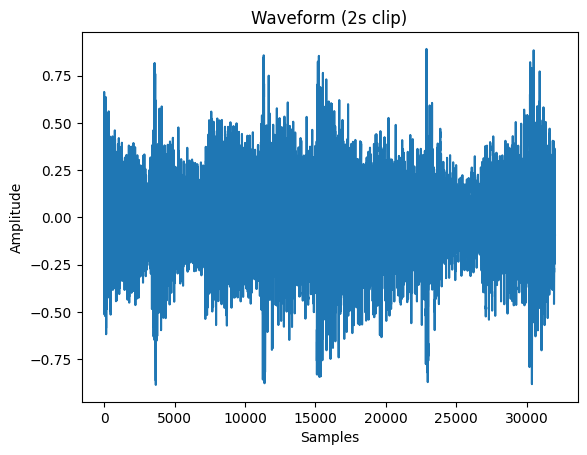

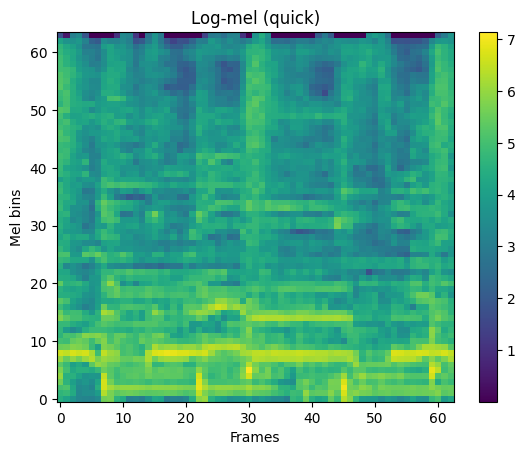

In [49]:
import matplotlib.pyplot as plt

try:
    from IPython.display import Audio, display
except Exception:
    Audio = None
    display = None

sample = train_dataset[0]
x = sample["audio"].detach().cpu()

plt.figure()
plt.plot(x.numpy())
plt.title("Waveform (2s clip)")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

melspec_tmp = MelSpectrogram(sample_rate=CFG["sample_rate"], n_mels=CFG["n_mels"], n_fft=CFG["n_fft"])
mel = torch.log10(1 + 1000 * melspec_tmp(x.unsqueeze(0))).squeeze(0).numpy()

plt.figure()
plt.imshow(mel, aspect="auto", origin="lower")
plt.title("Log-mel (quick)")
plt.xlabel("Frames")
plt.ylabel("Mel bins")
plt.colorbar()
plt.show()

if Audio is not None and display is not None:
    display(Audio(x.numpy(), rate=CFG["sample_rate"]))

**Feature extractor**

In [50]:
class FeatureExtractor(nn.Module):
    def __init__(self, n_mels=64, n_fft=1024):
        super().__init__()
        self.melspec = MelSpectrogram(sample_rate=CFG["sample_rate"], n_mels=n_mels, n_fft=n_fft)

    def forward(self, x):
        x = self.melspec(x)
        return torch.log10(1 + 1000 * x)

feature_extractor = FeatureExtractor(CFG["n_mels"], CFG["n_fft"]).to(device)

# <h3 style="text-align: left; font-weight: bold;">TRANSFORMER MODEL</h3>


In [51]:
class Transformer(nn.Module):
    def __init__(self, kernel=(8,8), stride=(4,4), n_blocks=2, emb_dim=64, n_heads=4, mlp_ratio=2,
                 output_size=50, pos_enc_gain=0.5, cls_token_ratio=0.25):
        super().__init__()
        self.emb_dim = emb_dim
        self.output_size = output_size
        self.pos_enc_gain = pos_enc_gain
        self.cls_token_ratio = cls_token_ratio

        self.norm = nn.BatchNorm2d(1)
        padding = kernel[0] // 2
        self.patching = nn.Conv2d(1, emb_dim, kernel_size=kernel, stride=stride, padding=padding)

        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(
                emb_dim, n_heads,
                dim_feedforward=emb_dim * mlp_ratio,
                dropout=0.1,
                norm_first=True
            ) for _ in range(n_blocks)
        ])

        self.cls = nn.Parameter(torch.randn(1,1,emb_dim))
        nn.init.normal_(self.cls, std=0.02)

        self.fc1 = nn.Linear(emb_dim, emb_dim)
        self.fc2 = nn.Linear(emb_dim, output_size)

    def positional_encoding(self, seq_len):
        position = torch.arange(seq_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, self.emb_dim, 2, dtype=torch.float32) * -(math.log(10000.0) / self.emb_dim))
        pe = torch.zeros(seq_len, self.emb_dim, device=self.cls.device)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.norm(x)
        x = self.patching(x)
        B, E, M, T = x.shape

        pe_m = self.positional_encoding(M)
        pe_t = self.positional_encoding(T)
        pe_m = pe_m.transpose(0,1).unsqueeze(0).unsqueeze(3)
        pe_t = pe_t.transpose(0,1).unsqueeze(0).unsqueeze(2)
        x = x + self.pos_enc_gain * (pe_m + pe_t)

        x = x.flatten(start_dim=2).swapaxes(1,2)
        cls = self.cls.repeat(B,1,1)
        x = torch.cat([cls, x], dim=1)

        for blk in self.blocks:
            x = blk(x)

        x_cls = x[:,0,:]
        x_mean = x[:,1:,:].mean(dim=1)
        x = self.cls_token_ratio * x_cls + (1 - self.cls_token_ratio) * x_mean

        x = F.layer_norm(x, (self.emb_dim,))
        x = F.relu(self.fc1(x))
        logits = self.fc2(x)
        return logits


class TLWav2Vec2Tagger(nn.Module):
    def __init__(self, n_classes, sample_rate=16000, backbone_name="wav2vec2_base", freeze=True, pool="mean"):
        super().__init__()
        if backbone_name == "wav2vec2_base":
            bundle = torchaudio.pipelines.WAV2VEC2_BASE
        elif backbone_name == "wav2vec2_base_960h":
            bundle = torchaudio.pipelines.WAV2VEC2_BASE_960H
        else:
            raise ValueError(f"Unknown tl_backbone: {backbone_name}")

        self.sample_rate = int(sample_rate)
        self.pool = str(pool)
        self.backbone = bundle.get_model()

        if freeze:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.emb_dim = int(bundle._params["encoder_embed_dim"])
        self.head = nn.Linear(self.emb_dim, int(n_classes))

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(0)
        feats, _ = self.backbone.extract_features(x)
        z = feats[-1]
        if self.pool == "mean":
            z = z.mean(dim=1)
        elif self.pool == "max":
            z = z.amax(dim=1)
        else:
            raise ValueError(f"Unknown tl_pool: {self.pool}")
        logits = self.head(z)
        return logits



# Models are buit later (TL + baseline). Basically for a fair comparison.
# This cell only defines the model classes.
# Commented section because redundant and cause a lot of workload in the CPU and it's time consuming.
'''
if CFG["mode"] == "baseline":
    model = Transformer(
        n_blocks=CFG["n_blocks"],
        emb_dim=CFG["emb_dim"],
        n_heads=CFG["n_heads"],
        stride=CFG["stride"],
        pos_enc_gain=CFG["pos_enc_gain"],
        cls_token_ratio=CFG["cls_token_ratio"],
        output_size=n_classes
    ).to(device)
else:
    model = TLWav2Vec2Tagger(
        n_classes=n_classes,
        sample_rate=CFG["sample_rate"],
        backbone_name=CFG["tl_backbone"],
        freeze=CFG["tl_freeze"],
        pool=CFG["tl_pool"],
    ).to(device)

sum(p.numel() for p in model.parameters() if p.requires_grad)
'''

'\nif CFG["mode"] == "baseline":\n    model = Transformer(\n        n_blocks=CFG["n_blocks"],\n        emb_dim=CFG["emb_dim"],\n        n_heads=CFG["n_heads"],\n        stride=CFG["stride"],\n        pos_enc_gain=CFG["pos_enc_gain"],\n        cls_token_ratio=CFG["cls_token_ratio"],\n        output_size=n_classes\n    ).to(device)\nelse:\n    model = TLWav2Vec2Tagger(\n        n_classes=n_classes,\n        sample_rate=CFG["sample_rate"],\n        backbone_name=CFG["tl_backbone"],\n        freeze=CFG["tl_freeze"],\n        pool=CFG["tl_pool"],\n    ).to(device)\n\nsum(p.numel() for p in model.parameters() if p.requires_grad)\n'

# <h2 style="text-align: center; font-weight: bold;">RESOURCE MONITOR AND ENVIRONMENTAL IMPACT</h2>

**Resource monitor (CPU, RAM and time)**

In [52]:
class ResourceMonitor:
    """
    aiming to track CPU%, RAM and the optional accelerator memory if available.
    so in summary:
    * CPU%: psutil.cpu_percent()
    * RAM MB: process RSS
    * GPU memory (CUDA): torch.cuda.memory_allocated()
    * MPS memory (Apple M1): torch.mps.current_allocated_memory() if available
    """
    def __init__(self, interval_s=1.0):
        self.interval_s = interval_s
        self.proc = psutil.Process(os.getpid())
        self.running = False
        self.samples = []
        self._t0 = None
        self._thread = None

    def _get_accel_mem_mb(self):
        # CUDA
        if torch.cuda.is_available():
            try:
                return float(torch.cuda.memory_allocated() / (1024**2))
            except Exception:
                return None
        # MPS (Apple Silicon or M1 technically)
        if hasattr(torch, "mps") and torch.backends.mps.is_available():
            try:
                if hasattr(torch.mps, "current_allocated_memory"):
                    return float(torch.mps.current_allocated_memory() / (1024**2))
            except Exception:
                return None
        return None

    def start(self):
        import threading
        self.running = True
        self._t0 = time.time()

        def loop():
            while self.running:
                t = time.time() - self._t0
                cpu = psutil.cpu_percent(interval=None)
                ram_mb = self.proc.memory_info().rss / (1024**2)
                accel_mb = self._get_accel_mem_mb()
                self.samples.append((t, cpu, ram_mb, accel_mb))
                time.sleep(self.interval_s)

        self._thread = threading.Thread(target=loop, daemon=True)
        self._thread.start()

    def stop(self):
        self.running = False
        time.sleep(self.interval_s)

    def summary(self):
        if not self.samples:
            return {}
        arr = np.array([[s[0], s[1], s[2], (s[3] if s[3] is not None else np.nan)] for s in self.samples], dtype=float)
        out = {
            "wall_time_s": float(arr[-1, 0]),
            "cpu_mean_pct": float(np.nanmean(arr[:, 1])),
            "cpu_max_pct": float(np.nanmax(arr[:, 1])),
            "ram_mean_mb": float(np.nanmean(arr[:, 2])),
            "ram_max_mb": float(np.nanmax(arr[:, 2])),
            "n_samples": int(len(self.samples)),
        }
        if not np.all(np.isnan(arr[:, 3])):
            out.update({
                "accel_mem_mean_mb": float(np.nanmean(arr[:, 3])),
                "accel_mem_max_mb": float(np.nanmax(arr[:, 3])),
            })
        return out

# <h3 style="text-align: left; font-weight: bold;">ROC AUC AND PR AUC METRICS </h3>

ROC-AUD and PR-AUC metrics plus fast training with early stop.

In [53]:
def forward_batch(model, batch, mode):
    x = batch["audio"].to(device)
    y = batch["labels"].to(device)

    if mode == "baseline":
        x_in = feature_extractor(x)
        logits = model(x_in)
    else:
        logits = model(x)

    probs = torch.sigmoid(logits)
    return logits, probs, y

def eval_auc(model, loader, mode):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for batch in loader:
            _, probs, y = forward_batch(model, batch, mode)
            ys.append(y.detach().cpu().numpy())
            ps.append(probs.detach().cpu().numpy())

    y_true = np.concatenate(ys, axis=0)
    y_score = np.concatenate(ps, axis=0)

    pos = y_true.sum(axis=0)
    n = y_true.shape[0]
    valid = (pos > 0) & (pos < n)

    n_valid = int(valid.sum())
    n_total = int(y_true.shape[1])

    if n_valid == 0:
        return float("nan"), float("nan"), {"valid_classes": 0, "total_classes": n_total, "dropped_classes": n_total}

    y_true_v = y_true[:, valid]
    y_score_v = y_score[:, valid]

    roc = roc_auc_score(y_true_v, y_score_v, average="macro")
    pr  = average_precision_score(y_true_v, y_score_v, average="macro")

    diag = {
        "valid_classes": n_valid,
        "total_classes": n_total,
        "dropped_classes": n_total - n_valid
    }
    return float(roc), float(pr), diag

def train_loop(model, mode, run_name="run"):
    os.makedirs("emissions", exist_ok=True)
    tracker = OfflineEmissionsTracker(
        country_iso_code="ESP",
        output_dir="emissions",
        output_file=f"codecarbon_emissions_{run_name}.csv",
        log_level="error"
    )
    monitor = ResourceMonitor(interval_s=1.0)

    optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
    loss_fn = nn.BCEWithLogitsLoss()

    best_pr = -1.0
    bad_epochs = 0
    history = []
    best_state = None

    tracker.start()
    monitor.start()

    try:
        for epoch in range(CFG["epochs"]):
            t0 = time.time()
            model.train()
            total_loss = 0.0

            pbar = tqdm(train_loader, desc=f"{run_name} | Epoch {epoch+1}/{CFG['epochs']}", leave=True)
            for step, batch in enumerate(pbar, start=1):
                logits, _, y = forward_batch(model, batch, mode)
                loss = loss_fn(logits, y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                pbar.set_postfix(loss=f"{loss.item():.4f}", avg=f"{(total_loss/step):.4f}")

            train_loss = total_loss / max(1, len(train_loader))
            val_roc, val_pr, val_diag = eval_auc(model, val_loader, mode)
            dt = time.time() - t0

            history.append({
                "epoch": epoch+1,
                "train_loss": float(train_loss),
                "val_roc": float(val_roc),
                "val_pr": float(val_pr),
                "epoch_time_s": float(dt),
                "val_valid_tags": int(val_diag["valid_classes"]),
                "val_total_tags": int(val_diag["total_classes"]),
                "val_dropped_tags": int(val_diag["dropped_classes"]),
            })

            if val_pr > best_pr + 1e-4:
                best_pr = float(val_pr)
                bad_epochs = 0
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            else:
                bad_epochs += 1
                if bad_epochs >= CFG["early_stop_patience"]:
                    print(f"{run_name} early stop at epoch {epoch+1} (best val PR-AUC={best_pr:.4f})")
                    break

            print(
                f"{run_name} | epoch {epoch+1:02d} | time={dt:.1f}s | train_loss={train_loss:.4f} | "
                f"val_ROC-AUC={val_roc:.4f} | val_PR-AUC={val_pr:.4f} | "
                f"valid_tags={val_diag['valid_classes']}/{val_diag['total_classes']}"
            )

        if best_state is not None:
            model.load_state_dict(best_state)

    finally:
        monitor.stop()
        emissions_kg = tracker.stop()
        resources = monitor.summary()

    test_roc, test_pr, test_diag = eval_auc(model, test_loader, mode)

    out = {
        "history": history,
        "test_roc": float(test_roc),
        "test_pr": float(test_pr),
        "test_diag": test_diag,
        "emissions_kg": emissions_kg,
        "resources": resources,
    }
    return out

tl | Epoch 1/10:   0%|          | 0/250 [00:00<?, ?it/s]

tl | epoch 01 | time=238.9s | train_loss=0.1049 | val_ROC-AUC=0.6170 | val_PR-AUC=0.0435 | valid_tags=186/188


tl | Epoch 2/10:   0%|          | 0/250 [00:00<?, ?it/s]

tl | epoch 02 | time=244.0s | train_loss=0.0708 | val_ROC-AUC=0.6691 | val_PR-AUC=0.0542 | valid_tags=186/188


tl | Epoch 3/10:   0%|          | 0/250 [00:00<?, ?it/s]

...

baseline | epoch 08 | time=99.5s | train_loss=0.0694 | val_ROC-AUC=0.7160 | val_PR-AUC=0.0635 | valid_tags=186/188


baseline | Epoch 9/10:   0%|          | 0/250 [00:00<?, ?it/s]

baseline | epoch 09 | time=100.5s | train_loss=0.0689 | val_ROC-AUC=0.7215 | val_PR-AUC=0.0673 | valid_tags=186/188


baseline | Epoch 10/10:   0%|          | 0/250 [00:00<?, ?it/s]

baseline | epoch 10 | time=102.3s | train_loss=0.0685 | val_ROC-AUC=0.7433 | val_PR-AUC=0.0698 | valid_tags=186/188

BASELINE params
Trainable params: 87,550 / Total params: 87,550

BASELINE SUMMARY
TEST ROC-AUC (macro): 0.7263
TEST PR-AUC  (macro): 0.0708
TEST valid_tags: 188/188 (dropped=0)
Emissions (kg CO2eq): 0.0005499134254755918
Resources summary: {'wall_time_s': 1032.8490149974823, 'cpu_mean_pct': 29.770428015564203, 'cpu_max_pct': 93.1, 'ram_mean_mb': 420.8598005836576, 'ram_max_mb': 647.46875, 'n_samples': 1028, 'accel_mem_mean_mb': 395.379299297407, 'accel_mem_max_mb': 683.9228515625}


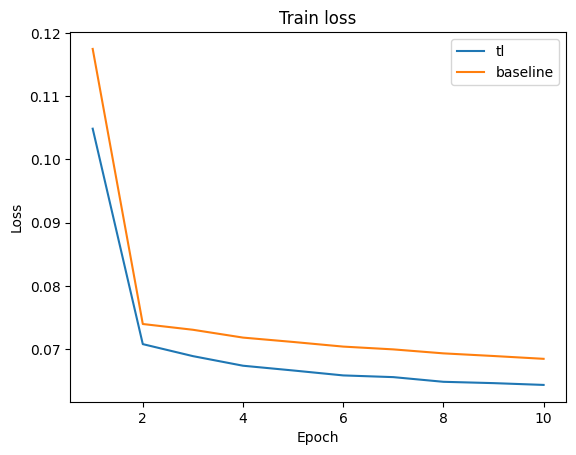

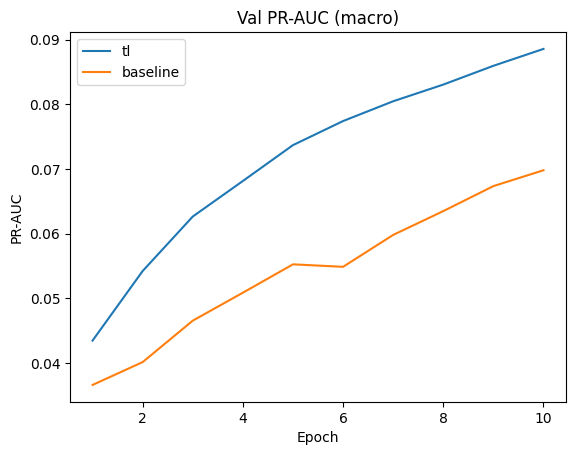

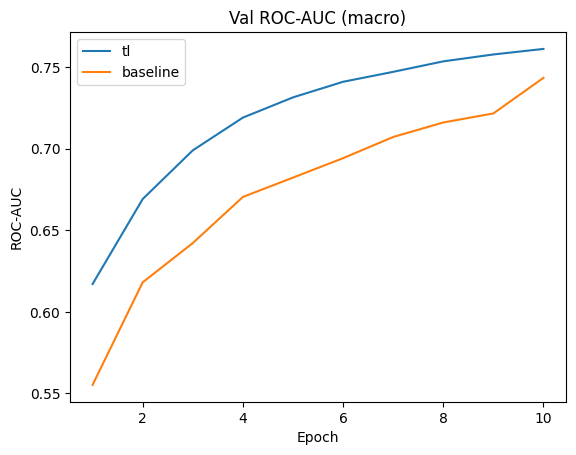

In [54]:
def build_model(mode):
    if mode == "baseline":
        return Transformer(
            n_blocks=CFG["n_blocks"],
            emb_dim=CFG["emb_dim"],
            n_heads=CFG["n_heads"],
            stride=CFG["stride"],
            pos_enc_gain=CFG["pos_enc_gain"],
            cls_token_ratio=CFG["cls_token_ratio"],
            output_size=n_classes
        ).to(device)
    else:
        return TLWav2Vec2Tagger(
            n_classes=n_classes,
            sample_rate=CFG["sample_rate"],
            backbone_name=CFG["tl_backbone"],
            freeze=CFG["tl_freeze"],
            pool=CFG["tl_pool"],
        ).to(device)

results = {}
trained_models = {}  # additional: keep trained models for final sanity checks..

for mode in ["tl", "baseline"]:
    m = build_model(mode)
    run_name = mode

    res = train_loop(m, mode=mode, run_name=run_name)

    # addi: store the trained model (already loaded with best_state inside train_loop)
    m.eval()
    trained_models[mode] = m

    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total = sum(p.numel() for p in m.parameters())
    print(color.BOLD + f"\n{mode.upper()} params" + color.END)
    print(f"Trainable params: {trainable:,} / Total params: {total:,}")
    results[mode] = res

    print(color.BOLD + f"\n{mode.upper()} SUMMARY" + color.END)
    print(f"TEST ROC-AUC (macro): {res['test_roc']:.4f}")
    print(f"TEST PR-AUC  (macro): {res['test_pr']:.4f}")
    print(f"TEST valid_tags: {res['test_diag']['valid_classes']}/{res['test_diag']['total_classes']} (dropped={res['test_diag']['dropped_classes']})")
    print("Emissions (kg CO2eq):", res["emissions_kg"])
    print("Resources summary:", res["resources"])

import pandas as pd
import matplotlib.pyplot as plt

df_tl = pd.DataFrame(results["tl"]["history"])
df_bl = pd.DataFrame(results["baseline"]["history"])

plt.figure()
plt.plot(df_tl["epoch"], df_tl["train_loss"], label="tl")
plt.plot(df_bl["epoch"], df_bl["train_loss"], label="baseline")
plt.title("Train loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(df_tl["epoch"], df_tl["val_pr"], label="tl")
plt.plot(df_bl["epoch"], df_bl["val_pr"], label="baseline")
plt.title("Val PR-AUC (macro)")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.legend()
plt.show()

plt.figure()
plt.plot(df_tl["epoch"], df_tl["val_roc"], label="tl")
plt.plot(df_bl["epoch"], df_bl["val_roc"], label="baseline")
plt.title("Val ROC-AUC (macro)")
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.legend()
plt.show()

# <h2 style="text-align: center; font-weight: bold;">FINAL TEST</h2>


### ALL RESULTS + ADDITIONAL: CODECARBON PLUS TRACKED TRAINING + SUMMARY


In [55]:
print(color.BOLD + "\nFINAL COMPARISON (TL vs BASELINE)" + color.END)
print(f"Device: {device}")
print(f"Train items: {len(train_df)} | Val items: {len(val_df)} | Test items: {len(test_df)}")
print(f"Tags/classes: {n_classes}")

for mode in ["tl", "baseline"]:
    res = results[mode]
    print(color.BOLD + f"\n{mode.upper()} FINAL" + color.END)
    print(f"TEST ROC-AUC (macro): {res['test_roc']:.4f}")
    print(f"TEST PR-AUC  (macro): {res['test_pr']:.4f}")
    print(f"TEST valid_tags: {res['test_diag']['valid_classes']}/{res['test_diag']['total_classes']} (dropped={res['test_diag']['dropped_classes']})")
    print("Emissions (kg CO2eq):", res["emissions_kg"])
    print("Resources summary:", res["resources"])




FINAL COMPARISON (TL vs BASELINE)
Device: mps
Train items: 8000 | Val items: 2000 | Test items: 2000
Tags/classes: 188

TL FINAL
TEST ROC-AUC (macro): 0.7621
TEST PR-AUC  (macro): 0.0868
TEST valid_tags: 188/188 (dropped=0)
Emissions (kg CO2eq): 0.001293008618316594
Resources summary: {'wall_time_s': 2430.143227815628, 'cpu_mean_pct': 23.911890999174236, 'cpu_max_pct': 90.1, 'ram_mean_mb': 815.8569170623451, 'ram_max_mb': 1159.28125, 'n_samples': 2422, 'accel_mem_mean_mb': 406.30812724181976, 'accel_mem_max_mb': 785.61328125}

BASELINE FINAL
TEST ROC-AUC (macro): 0.7263
TEST PR-AUC  (macro): 0.0708
TEST valid_tags: 188/188 (dropped=0)
Emissions (kg CO2eq): 0.0005499134254755918
Resources summary: {'wall_time_s': 1032.8490149974823, 'cpu_mean_pct': 29.770428015564203, 'cpu_max_pct': 93.1, 'ram_mean_mb': 420.8598005836576, 'ram_max_mb': 647.46875, 'n_samples': 1028, 'accel_mem_mean_mb': 395.379299297407, 'accel_mem_max_mb': 683.9228515625}


**CHECKS**

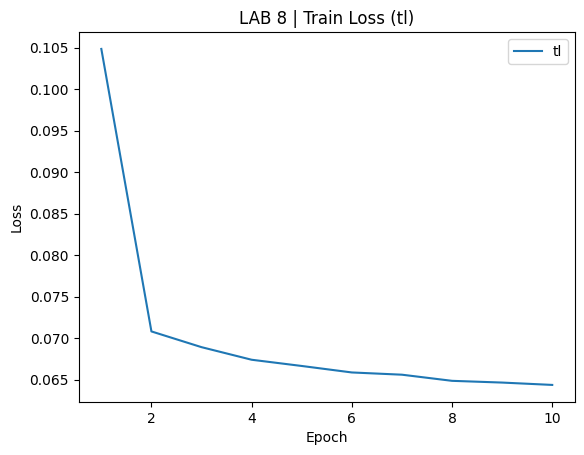

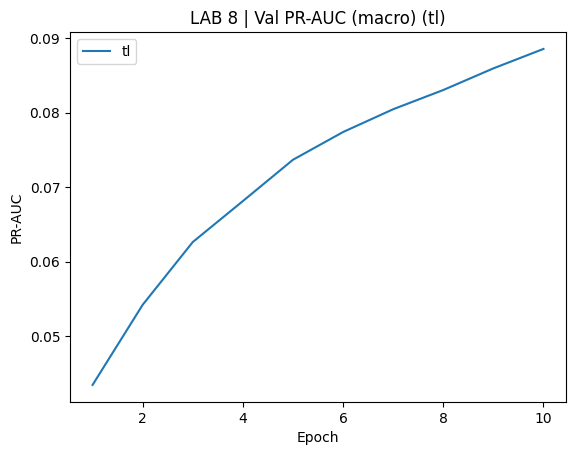

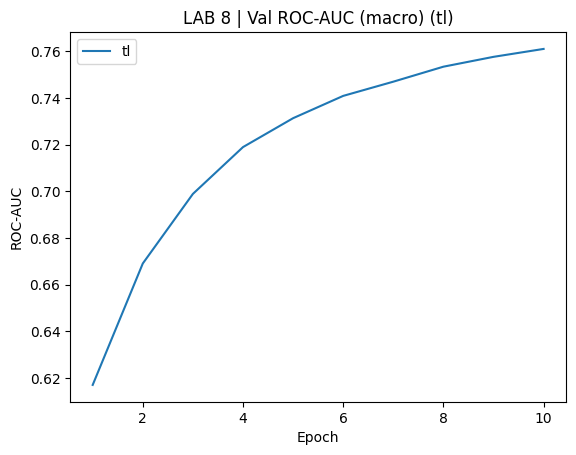

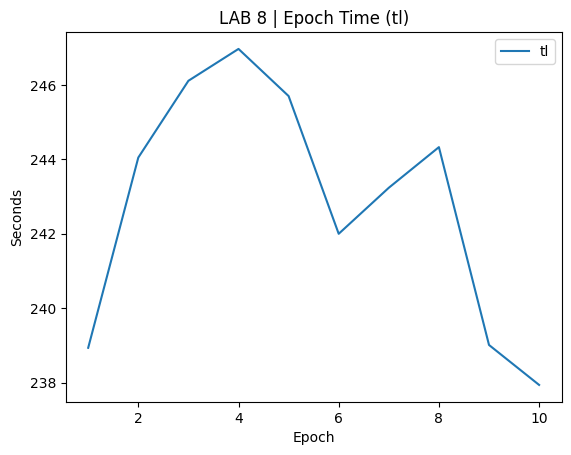

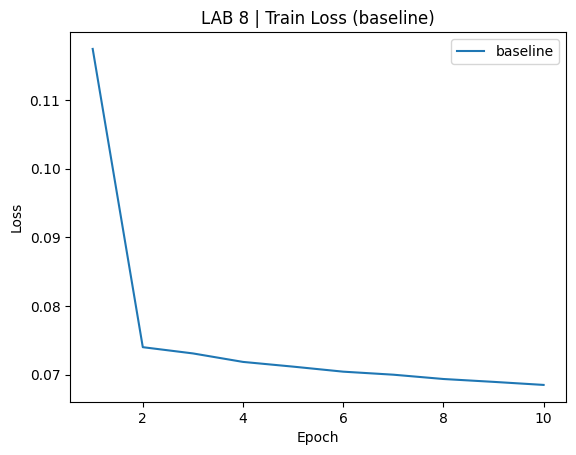

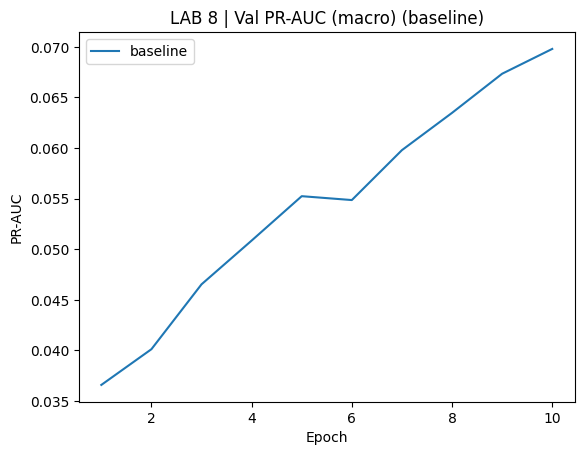

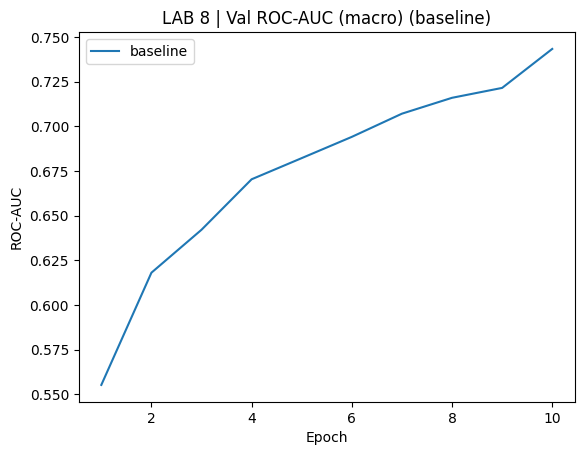

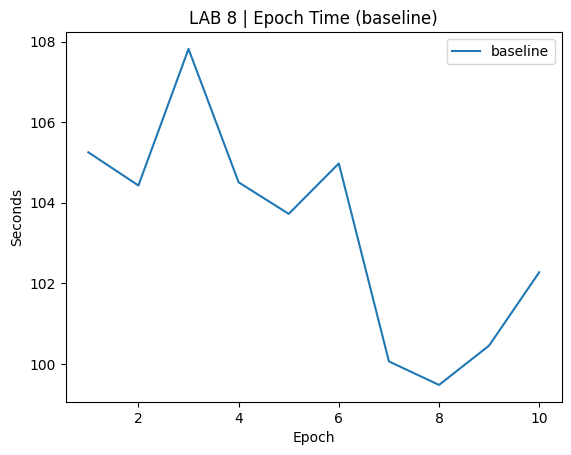

In [56]:
# SANITY CHECK 1: LEARNING CURVES (train loss / val PR-AUC / val ROC-AUC)
import pandas as pd
import matplotlib.pyplot as plt

def plot_history(results, title_prefix=""):
    for mode in ["tl", "baseline"]:
        if mode not in results:
            continue
        hist = results[mode]["history"]
        if not hist:
            print(f"No history for {mode}")
            continue

        df = pd.DataFrame(hist)

        plt.figure()
        plt.plot(df["epoch"], df["train_loss"], label=f"{mode}")
        plt.title(f"{title_prefix}Train Loss ({mode})")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(df["epoch"], df["val_pr"], label=f"{mode}")
        plt.title(f"{title_prefix}Val PR-AUC (macro) ({mode})")
        plt.xlabel("Epoch")
        plt.ylabel("PR-AUC")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(df["epoch"], df["val_roc"], label=f"{mode}")
        plt.title(f"{title_prefix}Val ROC-AUC (macro) ({mode})")
        plt.xlabel("Epoch")
        plt.ylabel("ROC-AUC")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(df["epoch"], df["epoch_time_s"], label=f"{mode}")
        plt.title(f"{title_prefix}Epoch Time ({mode})")
        plt.xlabel("Epoch")
        plt.ylabel("Seconds")
        plt.legend()
        plt.show()

plot_history(results, title_prefix="LAB 8 | ")

In [57]:
# SANITY CHECK 2: INFERENCE (Top-K tags) + AUDIO + GROUND TRUTH (multi-label)
import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    from IPython.display import Audio, display
except Exception:
    Audio = None
    display = None

def topk_tags(probs_1d, tag_cols, k=10):
    probs_1d = np.asarray(probs_1d).reshape(-1)
    idx = np.argsort(-probs_1d)[:k]
    return [(tag_cols[i], float(probs_1d[i])) for i in idx]

def infer_one(model, mode, x_1d_tensor):
    """
    x_1d_tensor: shape [T]
    returns probs: shape [n_classes]
    """
    model.eval()
    with torch.no_grad():
        x = x_1d_tensor.to(device)
        if x.dim() == 1:
            x = x.unsqueeze(0)  # [1, T]

        if mode == "baseline":
            x_in = feature_extractor(x)         # [B, n_mels, time]
            logits = model(x_in)
        else:
            logits = model(x)

        probs = torch.sigmoid(logits).squeeze(0).detach().cpu().numpy()
    return probs

def show_inference_on_sample(ds, idx, k=10):
    item = ds[int(idx)]
    x = item["audio"].detach().cpu()
    y = item["labels"].detach().cpu().numpy()

    # ground truth tags (where label==1)
    gt_idx = np.where(y > 0.5)[0].tolist()
    gt_tags = [TAG_COLS[i] for i in gt_idx]
    gt_tags = gt_tags[:30]  # avoid huge prints

    print(color.BOLD + f"\nSample idx={idx} | split={getattr(ds, 'split', 'unknown')}" + color.END)
    print(f"Ground-truth tags (first 30): {gt_tags}")

    # audio
    if Audio is not None and display is not None:
        display(Audio(x.numpy(), rate=CFG["sample_rate"]))

    # predictions
    for mode in ["tl", "baseline"]:
        probs = infer_one(trained_models[mode], mode, x)
        tk = topk_tags(probs, TAG_COLS, k=k)
        print(color.BOLD + f"\n{mode.upper()} Top-{k} predicted tags:" + color.END)
        for t, p in tk:
            print(f"  {t:20s}  p={p:.3f}")

# run on a few random test samples
rng = np.random.RandomState(SEED)
for _ in range(3):
    ridx = int(rng.randint(0, len(test_dataset)))
    show_inference_on_sample(test_dataset, ridx, k=10)


Sample idx=1126 | split=test
Ground-truth tags (first 30): ['rock']



TL Top-10 predicted tags:
  rock                  p=0.836
  metal                 p=0.488
  loud                  p=0.432
  hard rock             p=0.348
  guitar                p=0.290
  fast                  p=0.154
  heavy                 p=0.139
  drums                 p=0.136
  male                  p=0.116
  male vocal            p=0.105

BASELINE Top-10 predicted tags:
  guitar                p=0.442
  rock                  p=0.285
  slow                  p=0.182
  vocal                 p=0.176
  male                  p=0.173
  ambient               p=0.157
  loud                  p=0.143
  piano                 p=0.142
  singing               p=0.142
  male vocal            p=0.139

Sample idx=1459 | split=test
Ground-truth tags (first 30): []



TL Top-10 predicted tags:
  guitar                p=0.184
  drums                 p=0.129
  beat                  p=0.120
  slow                  p=0.089
  techno                p=0.078
  electronic            p=0.068
  fast                  p=0.053
  synth                 p=0.051
  vocal                 p=0.046
  female                p=0.040

BASELINE Top-10 predicted tags:
  techno                p=0.488
  electronic            p=0.413
  beat                  p=0.329
  drums                 p=0.294
  beats                 p=0.227
  synth                 p=0.168
  fast                  p=0.160
  guitar                p=0.137
  drum                  p=0.119
  dance                 p=0.090

Sample idx=860 | split=test
Ground-truth tags (first 30): ['no vocal', 'piano']



TL Top-10 predicted tags:
  slow                  p=0.412
  quiet                 p=0.332
  piano                 p=0.292
  guitar                p=0.181
  soft                  p=0.135
  ambient               p=0.091
  silence               p=0.060
  harp                  p=0.050
  classical             p=0.048
  low                   p=0.032

BASELINE Top-10 predicted tags:
  techno                p=0.336
  electronic            p=0.305
  beat                  p=0.250
  guitar                p=0.195
  drums                 p=0.169
  slow                  p=0.163
  synth                 p=0.147
  bass                  p=0.135
  beats                 p=0.127
  quiet                 p=0.095


In [58]:
# SANITY CHECK 3: TL vs BASELINE AGREEMENT (Top-K overlap / Jaccard)
import numpy as np

def jaccard(a, b):
    a, b = set(a), set(b)
    return len(a & b) / max(1, len(a | b))

def compare_models_on_sample(ds, idx, k=10):
    item = ds[int(idx)]
    x = item["audio"].detach().cpu()

    probs_tl = infer_one(trained_models["tl"], "tl", x)
    probs_bl = infer_one(trained_models["baseline"], "baseline", x)

    top_tl = [t for t, _ in topk_tags(probs_tl, TAG_COLS, k=k)]
    top_bl = [t for t, _ in topk_tags(probs_bl, TAG_COLS, k=k)]

    jac = jaccard(top_tl, top_bl)

    print(color.BOLD + f"\nCOMPARE idx={idx} | Top-{k} Jaccard={jac:.3f}" + color.END)
    print("TL top-k:", top_tl)
    print("BL top-k:", top_bl)

# compare on a few samples
for idx in [0, len(test_dataset)//3, (2*len(test_dataset))//3]:
    compare_models_on_sample(test_dataset, idx, k=10)


COMPARE idx=0 | Top-10 Jaccard=0.111
TL top-k: ['loud', 'techno', 'rock', 'synth', 'ambient', 'electronic', 'fast', 'metal', 'dance', 'drums']
BL top-k: ['guitar', 'ambient', 'slow', 'rock', 'vocal', 'piano', 'vocals', 'male', 'singing', 'male vocal']

COMPARE idx=666 | Top-10 Jaccard=0.250
TL top-k: ['guitar', 'rock', 'fast', 'drums', 'strings', 'classical', 'violin', 'country', 'male vocal', 'slow']
BL top-k: ['techno', 'electronic', 'drums', 'guitar', 'beat', 'synth', 'fast', 'beats', 'slow', 'drum']

COMPARE idx=1333 | Top-10 Jaccard=0.538
TL top-k: ['ambient', 'drums', 'synth', 'guitar', 'electronic', 'slow', 'fast', 'no vocals', 'flute', 'techno']
BL top-k: ['electronic', 'techno', 'drums', 'guitar', 'beat', 'synth', 'beats', 'fast', 'slow', 'drum']


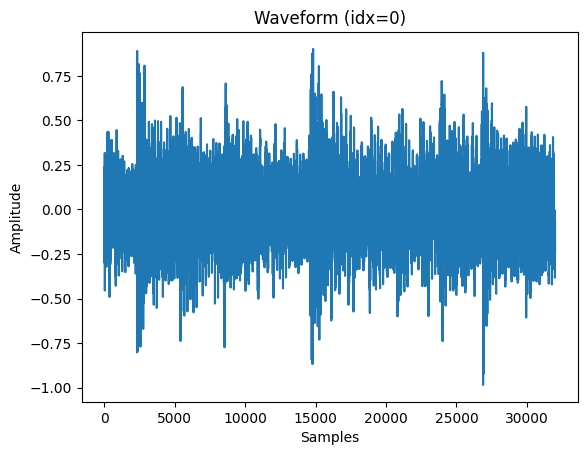

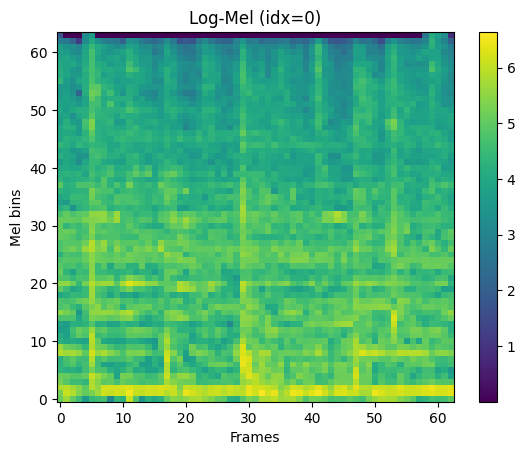

In [59]:
# SANITY CHECK 4: FEATURE VISUALIZATION (Waveform + Log-Mel) on a test sample
import matplotlib.pyplot as plt
import torch

def show_features(ds, idx):
    item = ds[int(idx)]
    x = item["audio"].detach().cpu()  # [T]

    plt.figure()
    plt.plot(x.numpy())
    plt.title(f"Waveform (idx={idx})")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.show()

    with torch.no_grad():
        mel = feature_extractor(x.unsqueeze(0).to(device)).squeeze(0).detach().cpu().numpy()

    plt.figure()
    plt.imshow(mel, aspect="auto", origin="lower")
    plt.title(f"Log-Mel (idx={idx})")
    plt.xlabel("Frames")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.show()

show_features(test_dataset, idx=0)


train | N=8000 | mean positive tags/sample=3.45

val | N=2000 | mean positive tags/sample=3.38

test | N=2000 | mean positive tags/sample=3.41


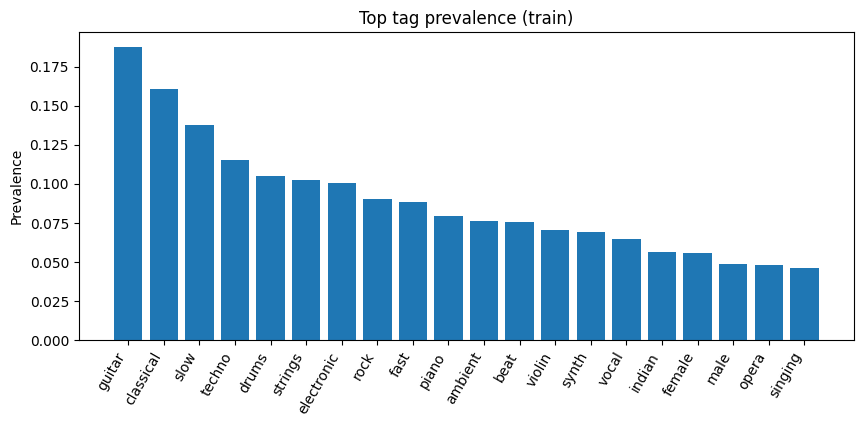

In [60]:
# SANITY CHECK 5: LABEL DISTRIBUTION (prevalence of tags) in train/val/test
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def tag_prevalence(df_split, name="split"):
    # df_split has clip_id, mp3_path
    clip_ids = df_split["clip_id"].values
    Y = ann_idx.loc[clip_ids, TAG_COLS].values.astype(np.float32)  # [N, C]
    prev = Y.mean(axis=0)  # prevalence per tag
    out = pd.DataFrame({"tag": TAG_COLS, "prevalence": prev}).sort_values("prevalence", ascending=False).reset_index(drop=True)
    print(color.BOLD + f"\n{name} | N={len(df_split)} | mean positive tags/sample={Y.sum(axis=1).mean():.2f}" + color.END)
    return out

prev_train = tag_prevalence(train_df, "train")
prev_val   = tag_prevalence(val_df, "val")
prev_test  = tag_prevalence(test_df, "test")

# plot top 20 tags of train
topN = 20
plt.figure(figsize=(10,4))
plt.bar(prev_train["tag"].head(topN), prev_train["prevalence"].head(topN))
plt.title("Top tag prevalence (train)")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Prevalence")
plt.show()

In [61]:
# SANITY CHECK 6: PREDICTION CONFIDENCE DIAGNOSTIC (are outputs non-trivial?)
import numpy as np

def confidence_stats(model, mode, ds, n=50):
    rng = np.random.RandomState(SEED)
    max_ps, mean_ps = [], []
    for _ in range(n):
        idx = int(rng.randint(0, len(ds)))
        x = ds[idx]["audio"].detach().cpu()
        probs = infer_one(model, mode, x)
        max_ps.append(float(np.max(probs)))
        mean_ps.append(float(np.mean(probs)))
    return {
        "max_p_mean": float(np.mean(max_ps)),
        "max_p_std": float(np.std(max_ps)),
        "mean_p_mean": float(np.mean(mean_ps)),
        "mean_p_std": float(np.std(mean_ps)),
    }

for mode in ["tl", "baseline"]:
    stats = confidence_stats(trained_models[mode], mode, test_dataset, n=80)
    print(color.BOLD + f"\n{mode.upper()} confidence stats on test:" + color.END)
    for k, v in stats.items():
        print(f"  {k}: {v:.4f}")


TL confidence stats on test:
  max_p_mean: 0.4318
  max_p_std: 0.1830
  mean_p_mean: 0.0188
  mean_p_std: 0.0052

BASELINE confidence stats on test:
  max_p_mean: 0.3822
  max_p_std: 0.0953
  mean_p_mean: 0.0235
  mean_p_std: 0.0039


In [62]:
import pandas as pd

def make_summary_table(results, device, train_df, val_df, test_df, n_classes):
    rows = []
    for mode in ["tl", "baseline"]:
        r = results[mode]
        # última fila de history (o mejor_epoch si guardas ese índice)
        last = r["history"][-1] if r["history"] else {}
        rows.append({
            "mode": mode,
            "device": device,
            "train_items": len(train_df),
            "val_items": len(val_df),
            "test_items": len(test_df),
            "tags": n_classes,
            "test_roc_macro": r["test_roc"],
            "test_pr_macro": r["test_pr"],
            "emissions_kg": r["emissions_kg"],
            "wall_time_s": r["resources"].get("wall_time_s", None),
            "cpu_mean_pct": r["resources"].get("cpu_mean_pct", None),
            "ram_max_mb": r["resources"].get("ram_max_mb", None),
            "accel_mem_max_mb": r["resources"].get("accel_mem_max_mb", None),
            "last_train_loss": last.get("train_loss", None),
            "last_val_roc": last.get("val_roc", None),
            "last_val_pr": last.get("val_pr", None),
        })
    return pd.DataFrame(rows)

summary_df = make_summary_table(results, device, train_df, val_df, test_df, n_classes)
summary_df

,mode,device,train_items,val_items,test_items,tags,test_roc_macro,test_pr_macro,emissions_kg,wall_time_s,cpu_mean_pct,ram_max_mb,accel_mem_max_mb,last_train_loss,last_val_roc,last_val_pr
0,tl,mps,8000,2000,2000,188,0.762073,0.08678,0.001293,2430.143228,23.911891,1159.28125,785.613281,0.064370,0.761027,0.088554
1,baseline,mps,8000,2000,2000,188,0.726340,0.07084,0.000550,1032.849015,29.770428,647.46875,683.922852,0.068493,0.743335,0.069793


In [63]:
history_df = pd.DataFrame(results["baseline"]["history"])   # o "tl"
history_df.tail(10)

,epoch,train_loss,val_roc,val_pr,epoch_time_s,val_valid_tags,val_total_tags,val_dropped_tags
0,1,0.117454,0.555201,0.036599,105.251535,186,188,2
1,2,0.073993,0.618042,0.040129,104.427825,186,188,2
2,3,0.073084,0.642090,0.046538,107.816116,186,188,2
3,4,0.071847,0.670350,0.050858,104.506716,186,188,2
4,5,0.071158,0.682197,0.055245,103.723573,186,188,2
5,6,0.070425,0.694096,0.054862,104.975005,186,188,2
6,7,0.069984,0.707079,0.059793,100.062536,186,188,2
7,8,0.069356,0.715966,0.063475,99.479908,186,188,2
8,9,0.068939,0.721506,0.067341,100.456729,186,188,2
9,10,0.068493,0.743335,0.069793,102.275962,186,188,2


In [64]:
summary_df.style.format({
    "test_roc_macro": "{:.4f}",
    "test_pr_macro": "{:.4f}",
    "emissions_kg": "{:.6f}",
    "wall_time_s": "{:.1f}",
    "cpu_mean_pct": "{:.1f}",
    "ram_max_mb": "{:.1f}",
    "accel_mem_max_mb": "{:.1f}",
    "last_train_loss": "{:.4f}",
    "last_val_roc": "{:.4f}",
    "last_val_pr": "{:.4f}",
})

,mode,device,train_items,val_items,test_items,tags,test_roc_macro,test_pr_macro,emissions_kg,wall_time_s,cpu_mean_pct,ram_max_mb,accel_mem_max_mb,last_train_loss,last_val_roc,last_val_pr
0,tl,mps,8000,2000,2000,188,0.7621,0.0868,0.001293,2430.1,23.9,1159.3,785.6,0.0644,0.7610,0.0886
1,baseline,mps,8000,2000,2000,188,0.7263,0.0708,0.000550,1032.8,29.8,647.5,683.9,0.0685,0.7433,0.0698


# <h2 style="text-align: center; font-weight: bold;">REPORT</h2>
